In [1]:
import pandas as pd
train_df=pd.read_csv('train.csv')
print(train_df.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


In [6]:

import pandas as pd
train_df = pd.read_csv('train.csv')

train_df[['Deck', 'Cabin_num', 'Side']] = train_df['Cabin'].str.split('/', expand=True)


train_df.drop(['Cabin', 'Name'], axis=1, inplace=True)


train_df['Deck'] = train_df['Deck'].fillna('Unknown')
train_df['Side'] = train_df['Side'].fillna('Unknown')

print("Success! Columns now available:", train_df.columns.tolist())

Success! Columns now available: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Deck', 'Cabin_num', 'Side']


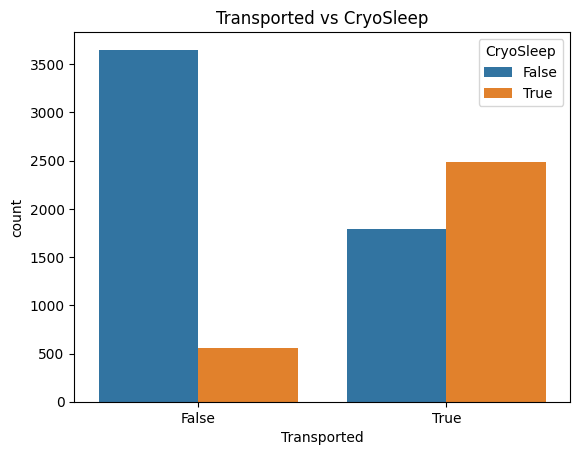

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=train_df, x='Transported', hue='CryoSleep')
plt.title('Transported vs CryoSleep')
plt.show()

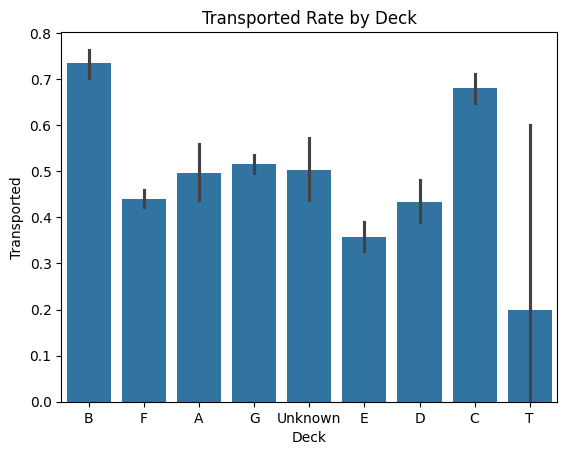

In [7]:
sns.barplot(data=train_df, x='Deck', y='Transported')
plt.title('Transported Rate by Deck')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

X = pd.get_dummies(train_df.drop('Transported', axis=1))
y = train_df['Transported'].astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)


model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4)



In [ ]:

for col in train_df.columns:
    if train_df[col].dtype in ['float64', 'int64']:
        train_df[col] = train_df[col].fillna(train_df[col].median())
    else:
        train_df[col] = train_df[col].fillna('Unknown')

X = pd.get_dummies(train_df.drop('Transported', axis=1))
y = train_df['Transported'].astype(int)


X = X.fillna(0) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Success! Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Success! Accuracy: 78.84%
